In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
plt.rcParams.update({'figure.dpi': 100})

In [2]:
def f(x, y):
    return x**2 / 20. + y**2

def df(x, y):
    return x/10. , 2. * y

Text(0, 0.5, 'y')

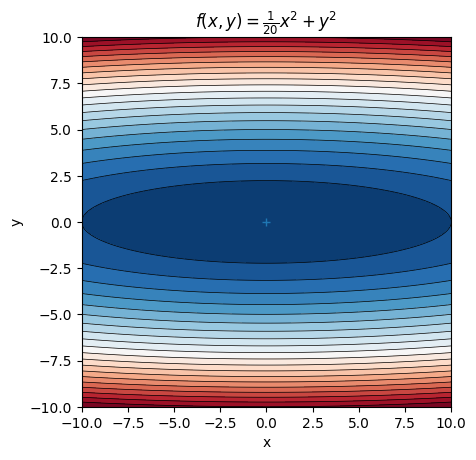

In [3]:
x = np.arange(-10, 10, 0.01)
y = np.arange(-10, 10, 0.01)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# mask = Z > 7
# Z[mask] = 0

plt.subplot(1, 1, 1).set_aspect('equal')
plt.contour(X, Y, Z, colors='black', levels=20, linewidths=0.5)
plt.contourf(X, Y, Z, levels=20, cmap='RdBu_r')
plt.ylim(-10, 10)
plt.xlim(-10, 10)
plt.plot(0, 0, '+')
plt.title(r'$f(x, y) = \frac{1}{20}x^2 + y^2$')
plt.xlabel('x')
plt.ylabel('y')

In [4]:
init_pos = {-7., 2.}
params = {}
params['x'], params['x'] = init_pos
grads = {}
grads['x'], grads['y'] = 0., 0.

In [5]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key] 

In [6]:
optimizers = OrderedDict()
optimizers['SGD'] = SGD(lr=0.95)

In [7]:
optimizer = optimizers['SGD']
x_history = []
y_history = []
params['x'], params['y'] = init_pos

for i in range(30):
    x_history.append(params['x'])
    y_history.append(params['y'])
    
    grads['x'], grads['y'] = df(params['x'], params['y'])
    optimizer.update(params, grads)

Text(0, 0.5, 'y')

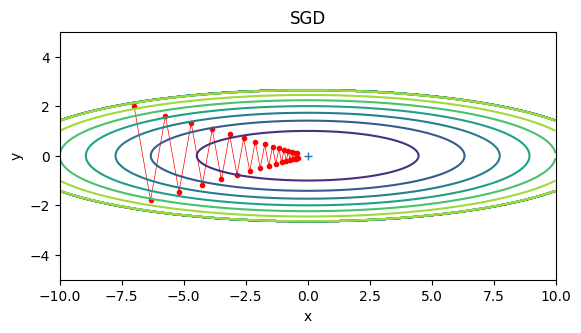

In [8]:
x = np.arange(-10, 10, 0.01)
y = np.arange(-5, 5, 0.01)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

mask = Z > 7
Z[mask] = 0

plt.subplot(1, 1, 1).set_aspect('equal')
plt.plot(x_history, y_history, 'o-', color='red', markersize=3, linewidth=0.5)
plt.contour(X, Y, Z)
plt.ylim(-5, 5)
plt.xlim(-10, 10)
plt.plot(0, 0, '+')
plt.title('SGD')
plt.xlabel('x')
plt.ylabel('y')

In [9]:
class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
        
        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

In [10]:
optimizers['Momentum'] = Momentum(lr=0.1)

In [11]:
optimizer = optimizers['Momentum']
x_history = []
y_history = []
params['x'], params['y'] = init_pos

for i in range(30):
    x_history.append(params['x'])
    y_history.append(params['y'])
    
    grads['x'], grads['y'] = df(params['x'], params['y'])
    optimizer.update(params, grads)

Text(0, 0.5, 'y')

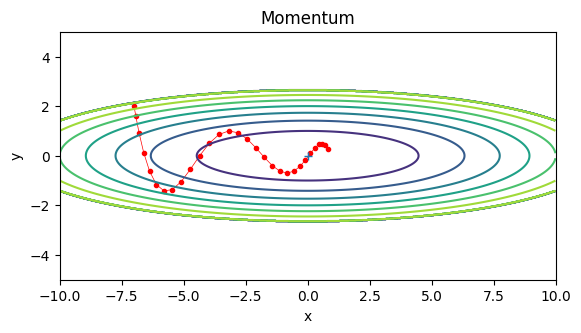

In [12]:
x = np.arange(-10, 10, 0.01)
y = np.arange(-5, 5, 0.01)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

mask = Z > 7
Z[mask] = 0

plt.subplot(1, 1, 1).set_aspect('equal')
plt.plot(x_history, y_history, 'o-', color='red', markersize=3, linewidth=0.5)
plt.contour(X, Y, Z)
plt.ylim(-5, 5)
plt.xlim(-10, 10)
plt.plot(0, 0, '+')
plt.title('Momentum')
plt.xlabel('x')
plt.ylabel('y')

In [13]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] /(np.sqrt(self.h[key]) + 1e-7)

In [14]:
optimizers['AdaGrad'] = AdaGrad(lr=1.5)

In [15]:
optimizer = optimizers['AdaGrad']
x_history = []
y_history = []
params['x'], params['y'] = init_pos

for i in range(30):
    x_history.append(params['x'])
    y_history.append(params['y'])
    
    grads['x'], grads['y'] = df(params['x'], params['y'])
    optimizer.update(params, grads)

Text(0, 0.5, 'y')

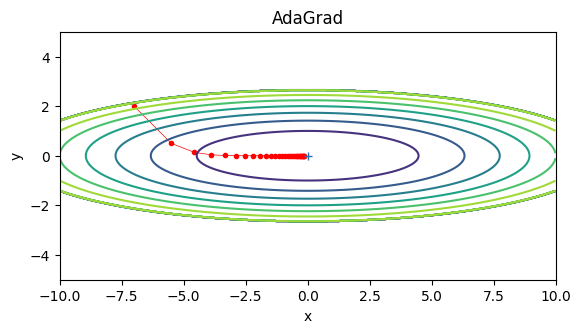

In [16]:
x = np.arange(-10, 10, 0.01)
y = np.arange(-5, 5, 0.01)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

mask = Z > 7
Z[mask] = 0

plt.subplot(1, 1, 1).set_aspect('equal')
plt.plot(x_history, y_history, 'o-', color='red', markersize=3, linewidth=0.5)
plt.contour(X, Y, Z)
plt.ylim(-5, 5)
plt.xlim(-10, 10)
plt.plot(0, 0, '+')
plt.title('AdaGrad')
plt.xlabel('x')
plt.ylabel('y')

In [17]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)         
        
        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

In [18]:
optimizers['Adam'] = Adam(lr=0.3)

In [22]:
optimizer = optimizers['Adam']
x_history = []
y_history = []
params['x'], params['y'] = init_pos

for i in range(300):
    x_history.append(params['x'])
    y_history.append(params['y'])
    
    grads['x'], grads['y'] = df(params['x'], params['y'])
    optimizer.update(params, grads)

Text(0, 0.5, 'y')

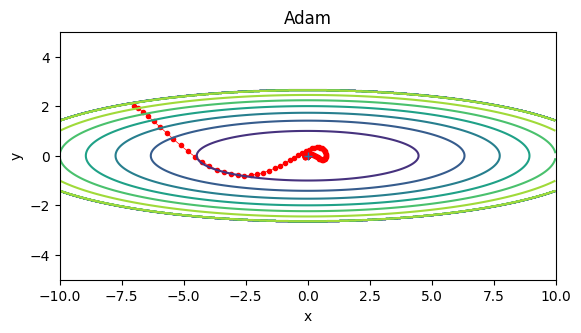

In [23]:
x = np.arange(-10, 10, 0.01)
y = np.arange(-5, 5, 0.01)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

mask = Z > 7
Z[mask] = 0

plt.subplot(1, 1, 1).set_aspect('equal')
plt.plot(x_history, y_history, 'o-', color='red', markersize=3, linewidth=0.5)
plt.contour(X, Y, Z)
plt.ylim(-5, 5)
plt.xlim(-10, 10)
plt.plot(0, 0, '+')
plt.title('Adam')
plt.xlabel('x')
plt.ylabel('y')

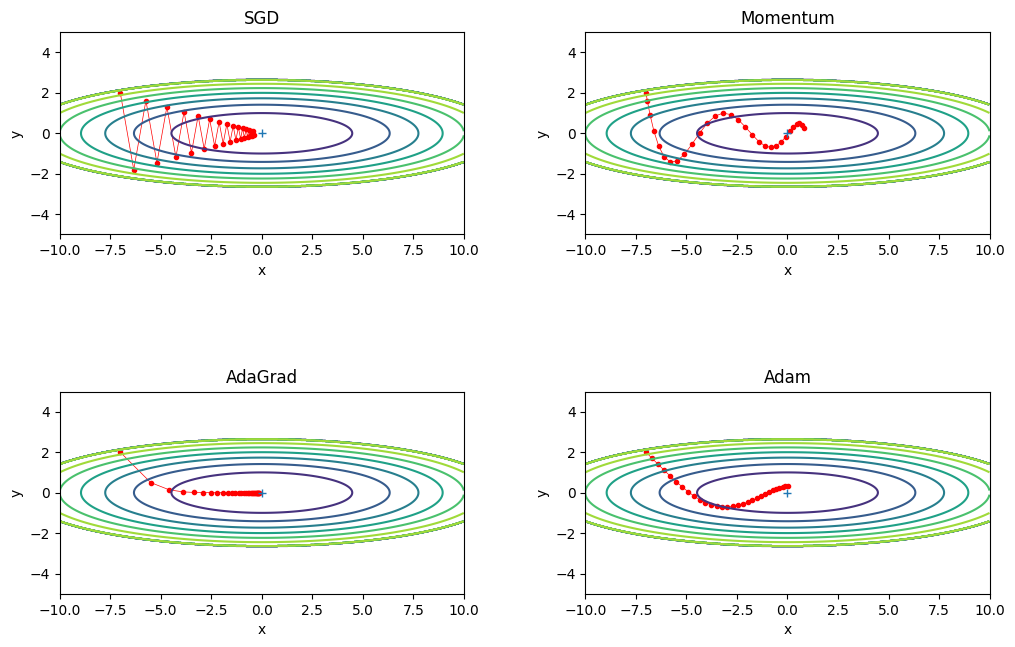

In [21]:
optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)
plt.figure(figsize=(12, 8))

idx = 1
for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0
    
    # 그래프 그리기
    plt.subplot(2, 2, idx).set_aspect('equal')
    idx += 1
    plt.plot(x_history, y_history, 'o-', color='red', markersize=3, linewidth=0.5)
    plt.contour(X, Y, Z)
    plt.ylim(-5, 5)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.subplots_adjust(wspace=0.3, hspace=0.4)    
plt.show()